# Proyecto Final Series de Tiempo
## Pronóstico de Llegada de Turistas Extranjeros a Chile

## Trabajo final del curso Series de Tiempo
Sara Gabriela Canga Gutierrez
<br>Erick Ramiro Barrios Rios
<br>Kelly Juliana Baez Vergara
<br>Heylen Gabriela Berrio Toloza
<br>Christian Andres Correa Baez


In [1]:
# LIBRERÍAS Y CONFIGURACIÓN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import itertools
import os

# Modelos de Series de Tiempo
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Configuración visual
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


Rango temporal: 2013-01-01 00:00:00 → 2025-06-01 00:00:00
Observaciones: 150


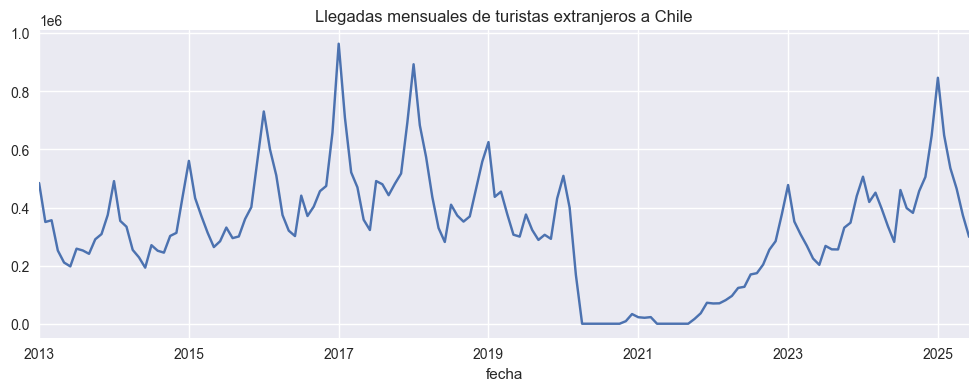

In [2]:
# Carga y limpieza de la base SERNATUR (CSV generado desde la web)
ruta = "ReporteTempPDI_1763779315451.csv"  

df_raw = pd.read_csv(ruta, encoding="latin1", sep=";")

# Filas útiles comienzan en la fila 7 (índice 7)
df = df_raw.iloc[7:].copy()

# Renombrar columnas relevantes
df = df.rename(columns={
    "Unnamed: 0": "n",
    "Unnamed: 1": "anio",
    "Unnamed: 2": "mes_nombre",
    "Unnamed: 3": "llegadas",
    "Unnamed: 4": "var12"
})[["n", "anio", "mes_nombre", "llegadas", "var12"]]

df["anio"] = df["anio"].astype(int)

mes_map = {
    "ENERO":1, "FEBRERO":2, "MARZO":3, "ABRIL":4,
    "MAYO":5, "JUNIO":6, "JULIO":7, "AGOSTO":8,
    "SEPTIEMBRE":9, "OCTUBRE":10, "NOVIEMBRE":11, "DICIEMBRE":12
}

df["mes_nombre"] = df["mes_nombre"].astype(str).str.strip().str.upper()
df["mes"] = df["mes_nombre"].map(mes_map)

df["llegadas"] = (
    df["llegadas"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

df["fecha"] = pd.to_datetime(dict(year=df["anio"], month=df["mes"], day=1))
df = df.set_index("fecha").sort_index()

serie = df["llegadas"].asfreq("MS")

print("Rango temporal:", serie.index.min(), "→", serie.index.max())
print("Observaciones:", len(serie))

serie.plot(figsize=(12,4), title="Llegadas mensuales de turistas extranjeros a Chile")
plt.grid(True)
plt.show()



Estadísticos descriptivos de la serie:


count       150.000000
mean     330258.806667
std      195442.789039
min           0.000000
25%      241682.500000
50%      330867.000000
75%      449007.750000
max      964027.000000
Name: llegadas, dtype: float64

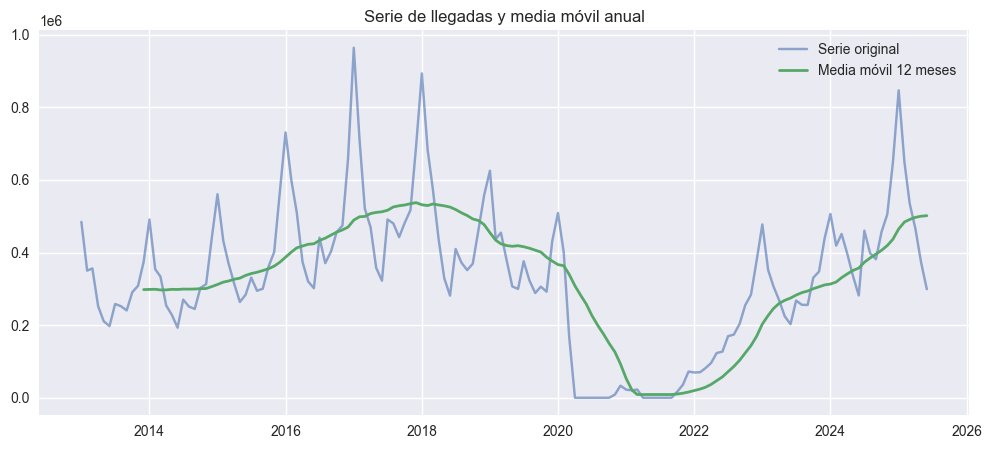

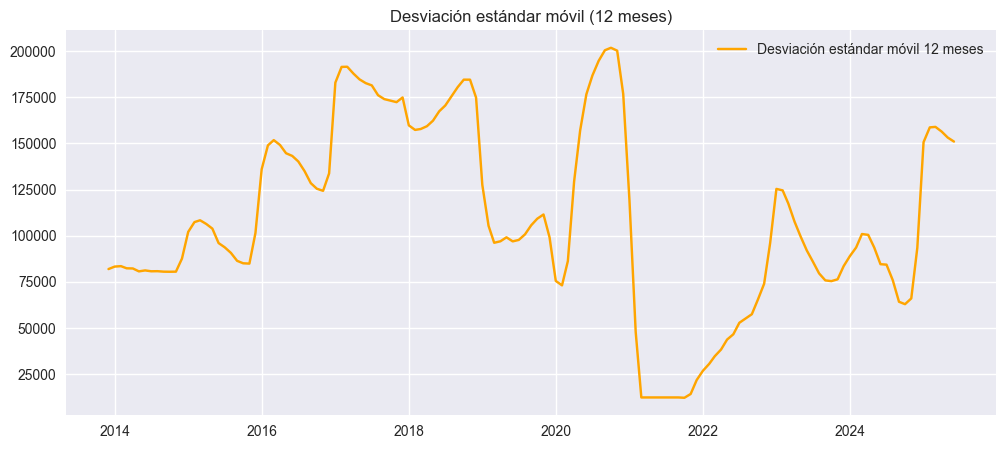

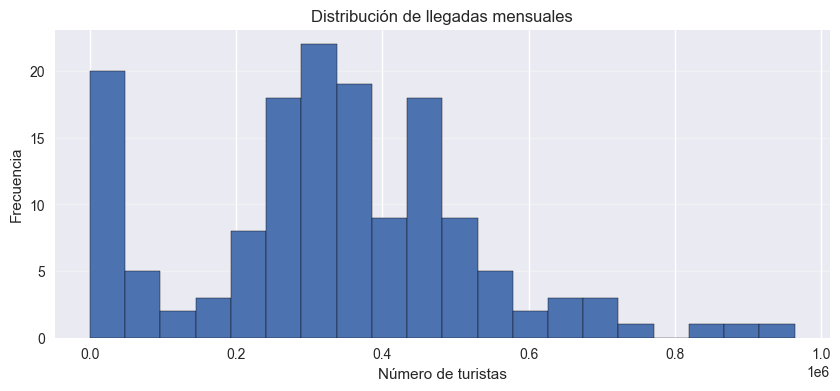

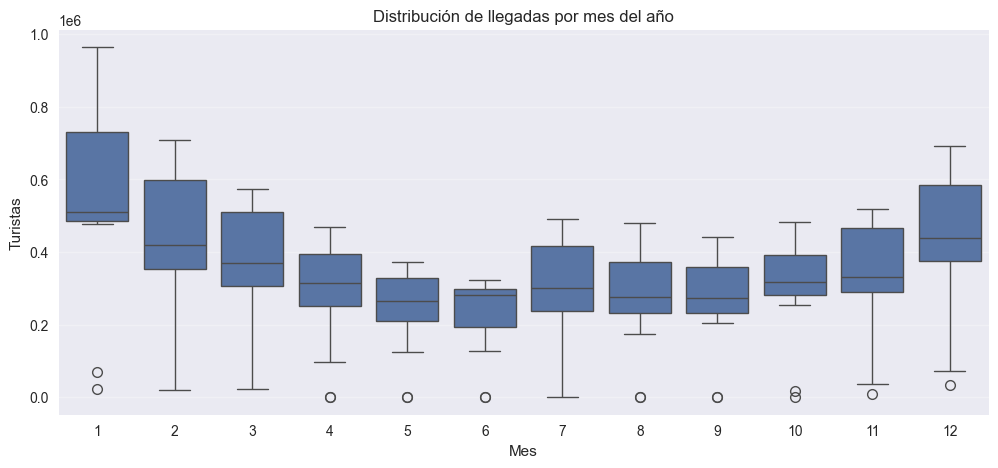

Test ADF en niveles:
  Estadístico ADF: -2.2967
  p-value        : 0.1730
  Valor crítico 1%: -3.4797
  Valor crítico 5%: -2.8832
  Valor crítico 10%: -2.5783

Conclusión: La serie NO es estacionaria en niveles (no se rechaza H0 al 5%).


In [3]:
# EXPLORACIÓN INICIAL DE LA SERIE

print("Estadísticos descriptivos de la serie:")
display(serie.describe())

# 1) Gráfico con media móvil
ventana = 12  # 12 meses ~ 1 año

rolling_mean = serie.rolling(window=ventana).mean()
rolling_std  = serie.rolling(window=ventana).std()

plt.figure(figsize=(12,5))
plt.plot(serie, label="Serie original", alpha=0.6)
plt.plot(rolling_mean, label=f"Media móvil {ventana} meses", linewidth=2)
plt.title("Serie de llegadas y media móvil anual")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(rolling_std, label=f"Desviación estándar móvil {ventana} meses", color="orange")
plt.title("Desviación estándar móvil (12 meses)")
plt.legend()
plt.grid(True)
plt.show()

# 2) Histograma de llegadas
plt.figure(figsize=(10,4))
plt.hist(serie.dropna(), bins=20, edgecolor="black")
plt.title("Distribución de llegadas mensuales")
plt.xlabel("Número de turistas")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 3) Boxplot por mes del año
#    (estacionalidad visual)
df_box = serie.to_frame(name="llegadas").copy()
df_box["mes"] = df_box.index.month

plt.figure(figsize=(12,5))
sns.boxplot(data=df_box, x="mes", y="llegadas")
plt.title("Distribución de llegadas por mes del año")
plt.xlabel("Mes")
plt.ylabel("Turistas")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 4) Test de estacionariedad ADF
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(serie.dropna())
print("Test ADF en niveles:")
print(f"  Estadístico ADF: {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.4f}")
for key, value in adf_result[4].items():
    print(f"  Valor crítico {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusión: La serie es estacionaria (se rechaza H0 al 5%).")
else:
    print("\nConclusión: La serie NO es estacionaria en niveles (no se rechaza H0 al 5%).")


In [4]:
# Partición Train / Test
train = serie.loc[: "2022-12-01"]
test  = serie.loc["2023-01-01":]

print("Train:", train.index.min(), "→", train.index.max(), f"({len(train)} obs)")
print("Test :", test.index.min(),  "→", test.index.max(),  f"({len(test)} obs)")

Train: 2013-01-01 00:00:00 → 2022-12-01 00:00:00 (120 obs)
Test : 2023-01-01 00:00:00 → 2025-06-01 00:00:00 (30 obs)


Naive simple  -> MAE: 105940.2  RMSE: 24048.90506031408
Naive estac.  -> MAE: 125295.63333333333  RMSE: 18642.030857715046


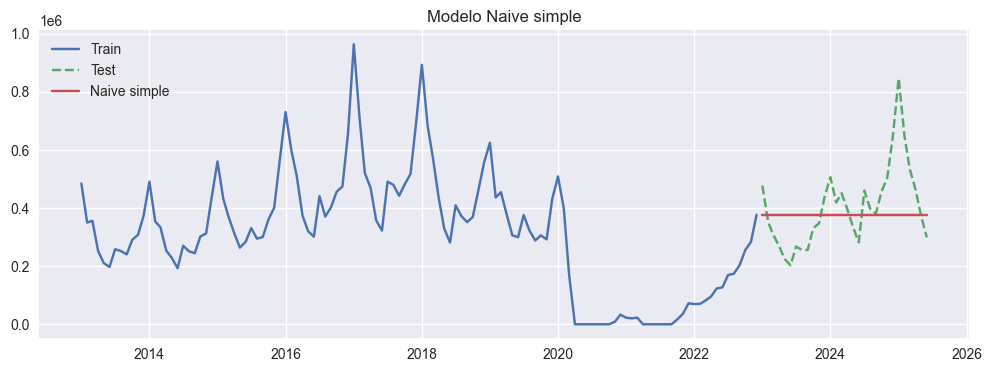

In [5]:
# 1) Modelos Naive

# Naive simple: último valor observado
naive_fc = pd.Series([train.iloc[-1]] * len(test), index=test.index)
mae_naive = mean_absolute_error(test, naive_fc)
rmse_naive = math.sqrt(mean_squared_error(test, naive_fc))

# Naive estacional: mismo mes del año anterior
seasonal_values = []
for date in test.index:
    prev_year = date - pd.DateOffset(years=1)
    if prev_year in train.index:
        seasonal_values.append(train.loc[prev_year])
    else:
        seasonal_values.append(train.iloc[-1])
snaive_fc = pd.Series(seasonal_values, index=test.index)
mae_snaive = mean_absolute_error(test, snaive_fc)
rmse_snaive = math.sqrt(mean_squared_error(test, snaive_fc))

print("Naive simple  -> MAE:", mae_naive,  " RMSE:", rmse_naive)
print("Naive estac.  -> MAE:", mae_snaive, " RMSE:", rmse_snaive)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linestyle="--")
plt.plot(test.index, naive_fc, label="Naive simple")
plt.title("Modelo Naive simple")
plt.legend()
plt.grid(True)
plt.show()


ETS Holt-Winters -> MAE: 133721.9862655915  RMSE: 159256.64701595512
AIC: 2664.668386226118  BIC: 2709.2682541106306


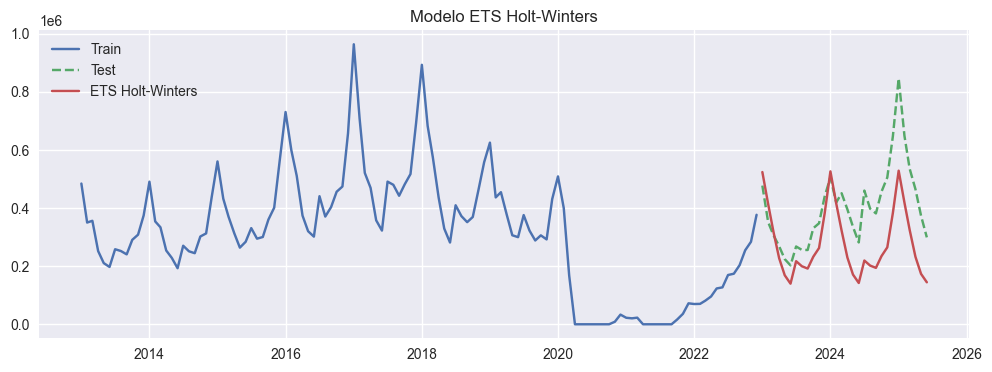

In [6]:
# 2) ETS Holt-Winters estacional (mejor ETS)

ets_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True)

ets_fc = ets_model.forecast(len(test))

mae_ets = mean_absolute_error(test, ets_fc)
rmse_ets = math.sqrt(mean_squared_error(test, ets_fc))

print("ETS Holt-Winters -> MAE:", mae_ets, " RMSE:", rmse_ets)
print("AIC:", ets_model.aic, " BIC:", ets_model.bic)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linestyle="--")
plt.plot(test.index, ets_fc, label="ETS Holt-Winters")
plt.title("Modelo ETS Holt-Winters")
plt.legend()
plt.grid(True)
plt.show()


STL + ETS -> MAE: 213577.78246142666  RMSE: 260849.61166452063
AIC componente ETS: 2355.8849113804927


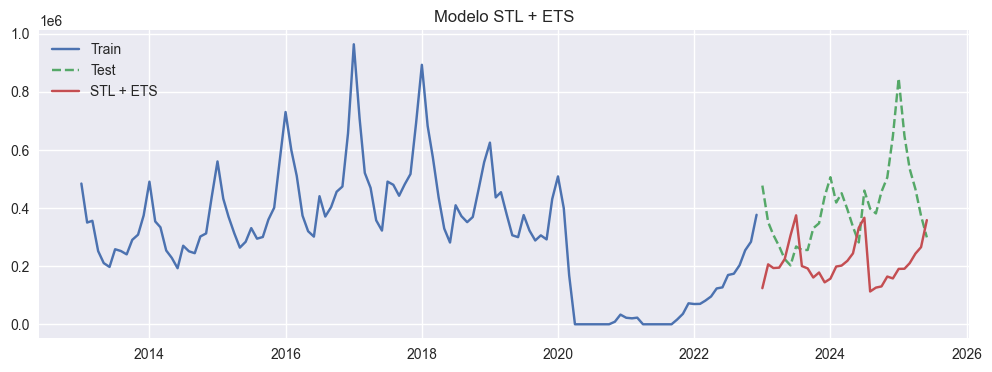

In [7]:
# 3) STL + ETS (descomposición + suavizamiento)

stl = STL(train.replace(0, np.nan).dropna(), period=12, robust=True).fit()
seasonal = stl.seasonal
trend_plus_resid = stl.trend + stl.resid

ets_stl = ExponentialSmoothing(
    trend_plus_resid,
    trend="add",
    seasonal=None
).fit()

h = len(test)
fc_tr = pd.Series(ets_stl.forecast(h).values, index=test.index)

last_season = seasonal.iloc[-h:]
S_future = pd.Series(np.resize(last_season.values, h), index=test.index)

stl_fc = fc_tr + S_future

mae_stl = mean_absolute_error(test, stl_fc)
rmse_stl = math.sqrt(mean_squared_error(test, stl_fc))

print("STL + ETS -> MAE:", mae_stl, " RMSE:", rmse_stl)
# AIC del ETS sobre componente no estacional
try:
    aic_stl = ets_stl.aic
except AttributeError:
    aic_stl = np.nan
print("AIC componente ETS:", aic_stl)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linestyle="--")
plt.plot(test.index, stl_fc, label="STL + ETS")
plt.title("Modelo STL + ETS")
plt.legend()
plt.grid(True)
plt.show()

ARIMA(2,1,2) -> MAE: 105373.86025911437  RMSE: 141702.67133766622
AIC: 3033.716469144188  BIC: 3047.612086609746


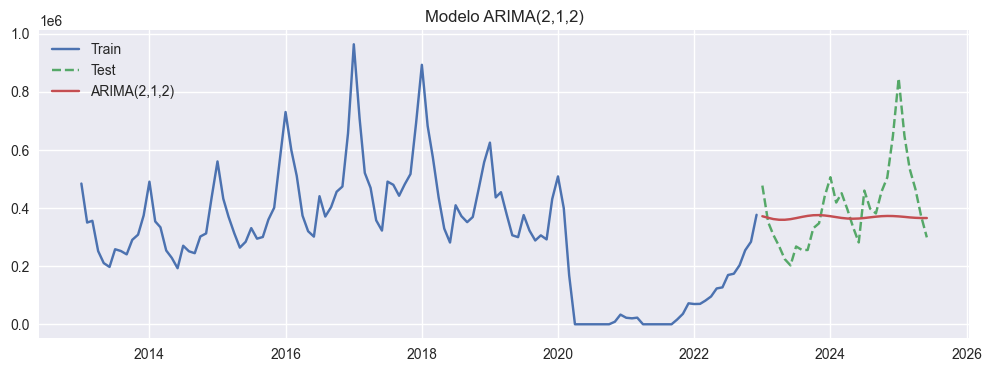

In [8]:
# 4) ARIMA(2,1,2) – mejor ARIMA

arima_order = (2, 1, 2)
arima_model = ARIMA(train, order=arima_order).fit()
arima_fc = arima_model.predict(start=test.index[0], end=test.index[-1])

mae_arima = mean_absolute_error(test, arima_fc)
rmse_arima = math.sqrt(mean_squared_error(test, arima_fc))

print("ARIMA(2,1,2) -> MAE:", mae_arima, " RMSE:", rmse_arima)
print("AIC:", arima_model.aic, " BIC:", arima_model.bic)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linestyle="--")
plt.plot(test.index, arima_fc, label="ARIMA(2,1,2)")
plt.title("Modelo ARIMA(2,1,2)")
plt.legend()
plt.grid(True)
plt.show()

SARIMA(2,1,2)(1,1,2)[12] -> MAE: 77177.72819198333  RMSE: 93160.6124204179
AIC: 1991.5941274038294  BIC: 2010.6503404812204


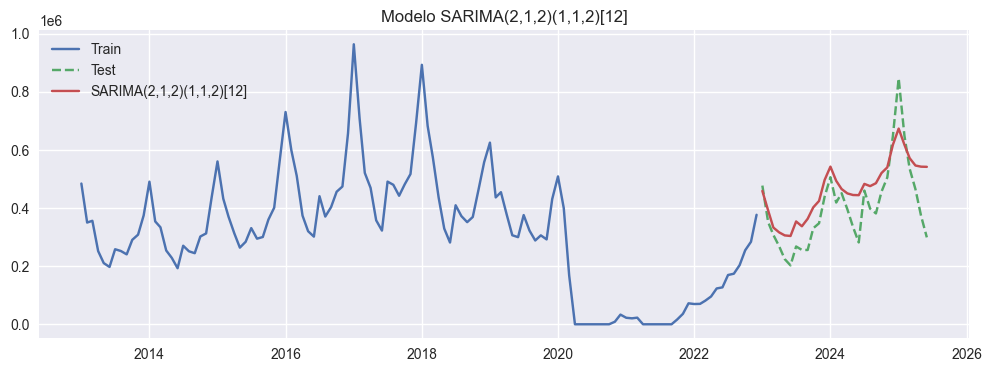

In [9]:
# 5) SARIMA(2,1,2) × (1,1,2)[12] – mejor SARIMA

sar_order = (2, 1, 2)
sar_seasonal = (1, 1, 2, 12)

sar_model = SARIMAX(
    train,
    order=sar_order,
    seasonal_order=sar_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sar_fc = sar_model.predict(start=test.index[0], end=test.index[-1])

mae_sar = mean_absolute_error(test, sar_fc)
rmse_sar = math.sqrt(mean_squared_error(test, sar_fc))

print("SARIMA(2,1,2)(1,1,2)[12] -> MAE:", mae_sar, " RMSE:", rmse_sar)
print("AIC:", sar_model.aic, " BIC:", sar_model.bic)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linestyle="--")
plt.plot(test.index, sar_fc, label="SARIMA(2,1,2)(1,1,2)[12]")
plt.title("Modelo SARIMA(2,1,2)(1,1,2)[12]")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# 6) Tabla comparativa final

resumen = pd.DataFrame([
    ["Naive simple", mae_naive, rmse_naive, np.nan, np.nan],
    ["Naive estacional", mae_snaive, rmse_snaive, np.nan, np.nan],
    ["ETS Holt-Winters", mae_ets, rmse_ets, ets_model.aic, ets_model.bic],
    ["STL + ETS", mae_stl, rmse_stl, aic_stl, np.nan],
    ["ARIMA(2,1,2)", mae_arima, rmse_arima, arima_model.aic, arima_model.bic],
    ["SARIMA(2,1,2)(1,1,2)[12]", mae_sar, rmse_sar, sar_model.aic, sar_model.bic],
], columns=["Modelo", "MAE", "RMSE", "AIC", "BIC"])

print("Resumen comparativo (menor es mejor en todas las métricas):")
display(resumen.sort_values("RMSE"))


Resumen comparativo (menor es mejor en todas las métricas):


,Modelo,MAE,RMSE,AIC,BIC
1,Naive estacional,125295.633333,18642.030858,NaN,NaN
0,Naive simple,105940.200000,24048.905060,NaN,NaN
5,"SARIMA(2,1,2)(1,1,2)[12]",77177.728192,93160.612420,1991.594127,2010.650340
4,"ARIMA(2,1,2)",105373.860259,141702.671338,3033.716469,3047.612087
2,ETS Holt-Winters,133721.986266,159256.647016,2664.668386,2709.268254
3,STL + ETS,213577.782461,260849.611665,2355.884911,NaN
